# clustering

In [1]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import DBSCAN, KMeans
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split


## test/train

In [35]:
df_all = pd.read_csv('goedeoutput.csv')

In [36]:
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434


In [41]:
colomn_names = df_all.columns
colomn_names

# colomnen verwijderen
feature_names=['time', 'x', 'y', 'z', 'abs', 'weather', 'roadtype']
Y = df_all['weight']
X = df_all[feature_names]
X = pd.get_dummies(X, columns=['weather','roadtype'], drop_first=True, dtype=int)
#Y = pd.get_dummies(Y, columns=['roadtype'], drop_first=True, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
colomn_names

Index(['time', 'x', 'y', 'z', 'abs', 'file', 'roadtype', 'weight', 'weather',
       'makers', 'second', 'x_std', 'y_std', 'z_std', 'x_mean', 'y_mean',
       'z_mean', 'x_rms', 'y_rms', 'z_rms', 'x_spectral_flatness',
       'y_spectral_flatness', 'z_spectral_flatness'],
      dtype='object')

## model

eps=0.5 | clusters=12 | noise=115 | silhouette=0.312
eps=1 | clusters=5 | noise=25 | silhouette=0.461
eps=1.5 | clusters=3 | noise=14 | silhouette=0.393
eps=2 | clusters=3 | noise=9 | silhouette=0.391
eps=3 | clusters=2 | noise=1 | silhouette=0.504
eps=4 | clusters=2 | noise=1 | silhouette=0.504
eps=5 | clusters=1 | noise=1

Beste eps: 3
Beste silhouette score: 0.504


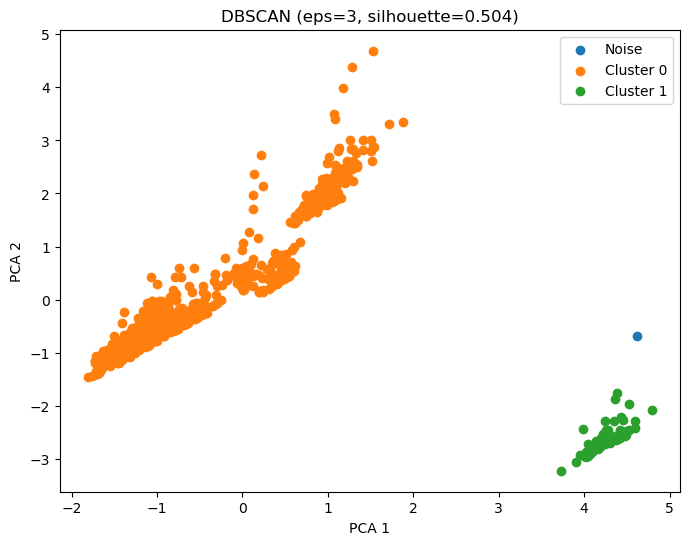

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# JOUW FEATURES
X = x_train

# Schalen
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA om dimensies te verminderen
pca = PCA(n_components=5)
X_pca5 = pca.fit_transform(X_scaled)

best_score = -999
best_labels = None
best_eps = None

for eps in [0.5, 1, 1.5, 2, 3, 4, 5]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_pca5)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters > 1:
        score = silhouette_score(X_pca5, labels)

        print(
            f"eps={eps} | "
            f"clusters={n_clusters} | "
            f"noise={n_noise} | "
            f"silhouette={score:.3f}"
        )

        if score > best_score:
            best_score = score
            best_labels = labels
            best_eps = eps

    else:
        print(
            f"eps={eps} | "
            f"clusters={n_clusters} | "
            f"noise={n_noise}"
        )

print("\nBeste eps:", best_eps)
print("Beste silhouette score:", round(best_score,3))

# PCA naar 2D voor plot
pca_plot = PCA(n_components=2)
X_plot = pca_plot.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in np.unique(best_labels):

    mask = best_labels == cluster

    if cluster == -1:
        plt.scatter(
            X_plot[mask,0],
            X_plot[mask,1],
            label="Noise"
        )
    else:
        plt.scatter(
            X_plot[mask,0],
            X_plot[mask,1],
            label=f"Cluster {cluster}"
        )

plt.title(
    f"DBSCAN (eps={best_eps}, silhouette={best_score:.3f})"
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [48]:
x_train_clustered = x_train.copy()

x_train_clustered["cluster"] = best_labels

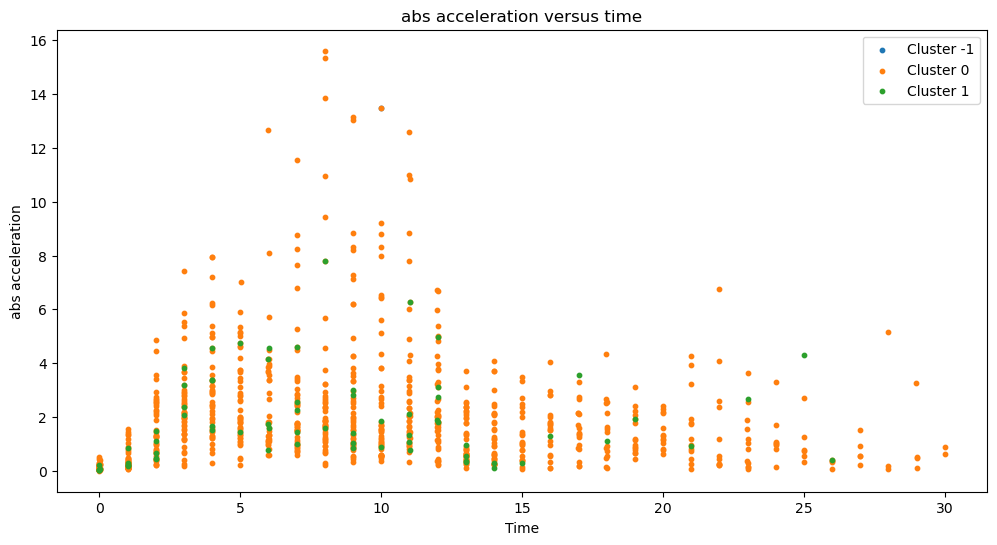

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for cluster in sorted(x_train_clustered["cluster"].unique()):

    mask = x_train_clustered["cluster"] == cluster

    plt.scatter(
        x_train_clustered.loc[mask, "time"],
        x_train_clustered.loc[mask, "abs"],
        label=f"Cluster {cluster}",
        s=10
    )

plt.xlabel("Time")
plt.ylabel("abs acceleration")
plt.title("abs acceleration versus time")
plt.legend()
plt.show()

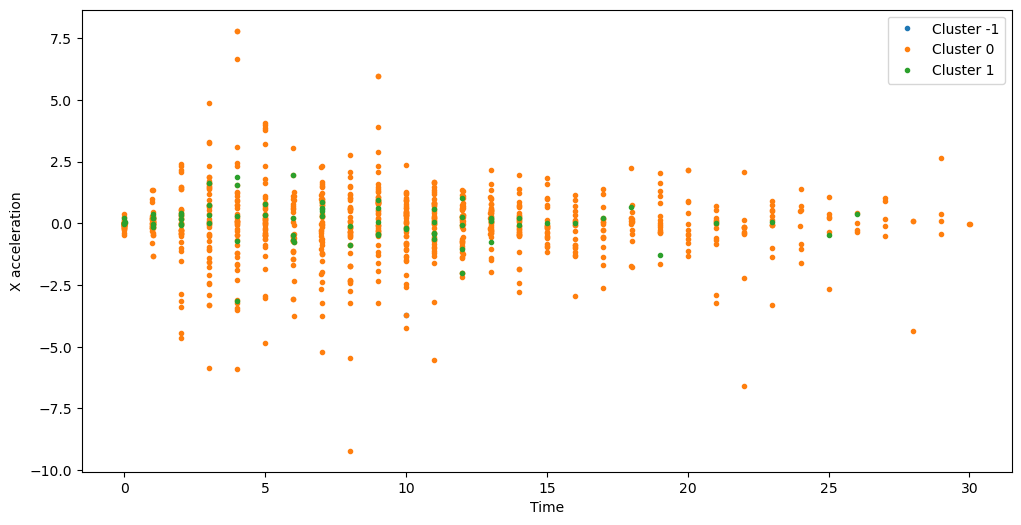

In [51]:
plt.figure(figsize=(12,6))

for cluster in sorted(x_train_clustered["cluster"].unique()):

    mask = x_train_clustered["cluster"] == cluster

    plt.plot(
        x_train_clustered.loc[mask, "time"],
        x_train_clustered.loc[mask, "x"],
        '.',
        label=f"Cluster {cluster}"
    )

plt.xlabel("Time")
plt.ylabel("X acceleration")
plt.legend()
plt.show()

In [52]:
x_train_clustered

,time,x,y,z,abs,weather_Dry,weather_Wet,roadtype_bricks,roadtype_grass,roadtype_gravel,roadtype_sand,roadtype_wood,cluster
105125,4.002599,0.730373,-2.118430,-1.015663,2.460236,0,0,0,0,0,0,0,0
87960,20.007945,0.410396,-0.581452,1.101921,1.311770,1,0,0,0,1,0,0,0
99493,6.003994,-0.677692,0.509256,0.824886,1.182812,0,0,0,0,0,0,0,0
105828,11.000076,0.223421,-0.531689,2.903224,2.959953,0,0,0,0,0,0,0,0
28256,16.000612,-0.078366,-0.049826,-0.008698,0.093271,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49448,14.000041,1.229497,1.128203,-1.273936,2.099385,1,0,0,0,1,0,0,0
11678,14.005690,0.297927,-1.293568,0.780759,1.540020,1,0,0,0,0,0,1,0
115180,6.000826,0.197321,-1.063524,-1.358685,1.736676,0,1,0,0,0,1,0,1
120193,15.007198,0.024373,0.242879,0.136322,0.279585,0,1,0,0,0,1,0,1


Aantal clusters: 18
Silhouette score: -0.211


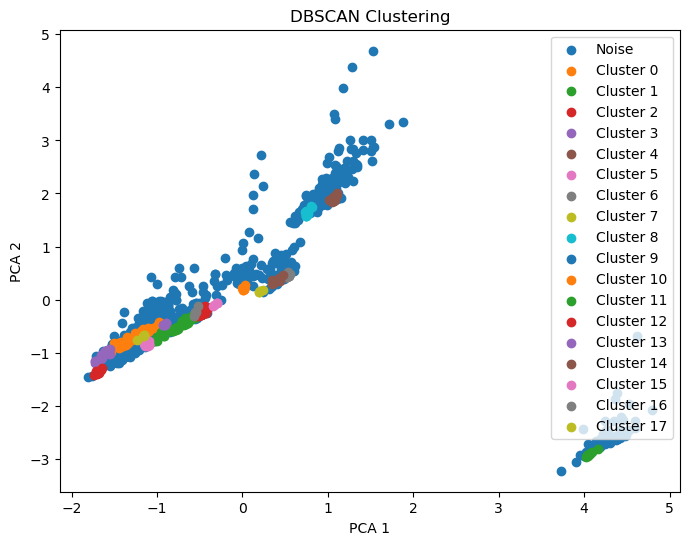

In [46]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# JOUW FEATURES
X = x_train

# Schalen
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
    leaf_size=30
)

labels = dbscan.fit_predict(X_scaled)

# Aantal clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Aantal clusters:", n_clusters)

# Silhouette score
if n_clusters > 1:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette score:", round(score,3))
else:
    print("Geen silhouette score mogelijk.")

# PCA plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for cluster in np.unique(labels):
    mask = labels == cluster

    if cluster == -1:
        plt.scatter(
            X_pca[mask,0],
            X_pca[mask,1],
            label="Noise"
        )
    else:
        plt.scatter(
            X_pca[mask,0],
            X_pca[mask,1],
            label=f"Cluster {cluster}"
        )

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = x_train

best_score = -1
best_k = None

for k in range(2, 8):

    pipeline = make_pipeline(
        StandardScaler(),
        KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )
    )

    labels = pipeline.fit_predict(X)

    score = silhouette_score(X, labels)

    print(f"k={k}: {score:.3f}")

    if score > best_score:
        best_score = score
        best_k = k

print()
print("Beste aantal clusters:", best_k)
print("Beste silhouette score:", best_score)

c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=2: 0.148
k=3: 0.040


c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=4: -0.022
k=5: -0.028


c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\laure\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=6: -0.059
k=7: -0.052

Beste aantal clusters: 2
Beste silhouette score: 0.14756354966705276


In [5]:
pipeline = make_pipeline(StandardScaler(), DBSCAN()) #max_iter=1000, tol=1e-3))

param_grid = {
    'dbscan__eps': [0.2,0.5,1],
    'dbscan__leaf_size': [15, 30, 45],
    'dbscan__min_samples': [5, 10]


}
grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=4, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)


TypeError: If no scoring is specified, the estimator passed should have a 'score' method. The estimator Pipeline(steps=[('standardscaler', StandardScaler()), ('dbscan', DBSCAN())]) does not.

In [6]:
# Perform DBSCAN clustering
epsilon = 0.7  # Chosen based on k-distance graph
min_samples = 6  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(x_train)
# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=clusters, cmap='viridis')
plt.legend()
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

<Figure size 1000x600 with 0 Axes>

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# DBSCAN
epsilon = 1
min_samples = 6

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(x_train)

clusters

array([-1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  2, -1,  3, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  4, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  3, -1, -1, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  2, -1, -1, -1, -1, -1, -1,
        4, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1,
       -1, -1, -1, -1, -1

In [ ]:
from sklearn import metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

NameError: name 'labels' is not defined

In [ ]:
KMeans.fit(x_train)

AttributeError: 'DataFrame' object has no attribute '_validate_params'

In [32]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2, random_state=42)

clusters = model.fit_predict(X)
df_all['cluster']=clusters

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


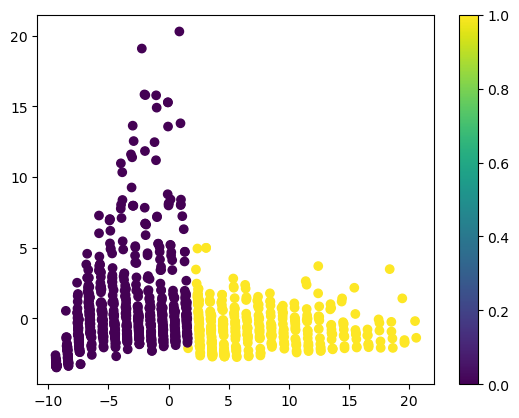

In [36]:
psa = PCA(n_components=2)

x_psa =  psa.fit_transform(X)
plt.scatter(x_psa[:,0],x_psa[:,1], c= clusters)
plt.colorbar()

In [41]:
df_all.x.value_counts

<bound method IndexOpsMixin.value_counts of 0        -0.388200
99       -0.180555
199      -4.626964
298       3.016697
398      -0.492856
            ...   
120896    0.656172
120997    0.064936
121097    0.054262
121197   -0.465913
121298    0.392996
Name: x, Length: 1107, dtype: float64>

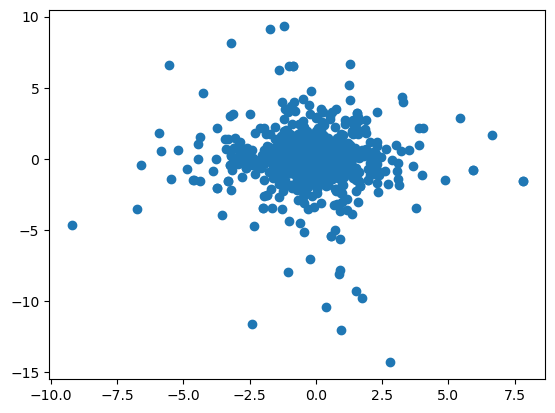

In [37]:
plt.scatter(df_all.x, df_all.y)

In [33]:
df_all

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness,cluster
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.00,Dry,Laurence & Doris,...,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400,0
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212,0
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.00,Dry,Laurence & Doris,...,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190,0
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120896,22.004517,0.656172,0.098579,-0.148127,0.679869,zand_5kg_second_22,sand,5.75,Wet,Liz & Renske,...,-0.253706,0.008000,0.149668,0.633183,1.684808,2.056143,0.628787,0.560213,0.579388,1
120997,23.009828,0.064936,2.168097,1.586151,2.687143,zand_5kg_second_23,sand,5.75,Wet,Liz & Renske,...,0.095871,-0.069747,0.121144,0.713378,1.350980,1.702503,0.717287,0.681901,0.643996,1
121097,24.005186,0.054262,-1.209899,0.453583,1.293266,zand_5kg_second_24,sand,5.75,Wet,Liz & Renske,...,0.035572,-0.780466,1.578790,0.706340,2.208710,3.108693,0.741640,0.602472,0.550879,1
121197,25.000545,-0.465913,-2.656772,3.367562,4.314625,zand_5kg_second_25,sand,5.75,Wet,Liz & Renske,...,-0.177443,-0.554232,1.005843,0.847816,1.113331,1.846340,0.666976,0.591709,0.551925,1


# test 123

In [109]:
X

,x,y,z,abs,weight,second,x_std,y_std,z_std,x_mean,...,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness,weather_Dry,weather_Wet,roadtype_bricks,roadtype_grass,roadtype_gravel,roadtype_sand,roadtype_wood
0,-0.388200,-0.164216,0.007704,0.421575,0.00,0,0.373276,0.169392,0.140477,0.067120,...,0.522432,0.731454,0.653138,1,0,0,0,0,0,0
99,-0.180555,0.701490,-0.055554,0.726481,0.00,1,2.181070,1.220897,0.575868,-0.722286,...,0.464260,0.505939,0.574400,1,0,0,0,0,0,0
199,-4.626964,-1.482370,0.379587,4.873428,0.00,2,2.370932,1.346197,0.916088,0.911198,...,0.531467,0.642817,0.745212,1,0,0,0,0,0,0
298,3.016697,0.947292,-0.673180,3.232800,0.00,3,3.425790,1.252378,0.862473,-0.349491,...,0.396479,0.540455,0.702190,1,0,0,0,0,0,0
398,-0.492856,1.994679,0.532708,2.122600,0.00,4,2.177802,0.957721,0.736694,0.466448,...,0.466821,0.642661,0.828434,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120896,0.656172,0.098579,-0.148127,0.679869,5.75,22,0.583027,1.693192,2.060916,-0.253706,...,0.628787,0.560213,0.579388,0,1,0,0,0,1,0
120997,0.064936,2.168097,1.586151,2.687143,5.75,23,0.710467,1.355975,1.706743,0.095871,...,0.717287,0.681901,0.643996,0,1,0,0,0,1,0
121097,0.054262,-1.209899,0.453583,1.293266,5.75,24,0.708997,2.076631,2.691437,0.035572,...,0.741640,0.602472,0.550879,0,1,0,0,0,1,0
121197,-0.465913,-2.656772,3.367562,4.314625,5.75,25,0.833174,0.970390,1.556029,-0.177443,...,0.666976,0.591709,0.551925,0,1,0,0,0,1,0


In [110]:
X = df_all.drop(columns=['time','cluster','file','makers'])
X = pd.get_dummies(X, columns=['weather','roadtype'], drop_first=True, dtype=int)

In [111]:

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42)
df_all['cluster'] = kmeans.fit_predict(x_scaled)
df_all.head()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness,cluster
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400,0
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212,0
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190,0
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434,0


In [114]:
df_all["cluster"].value_counts()


cluster
0    1016
1      91
Name: count, dtype: int64

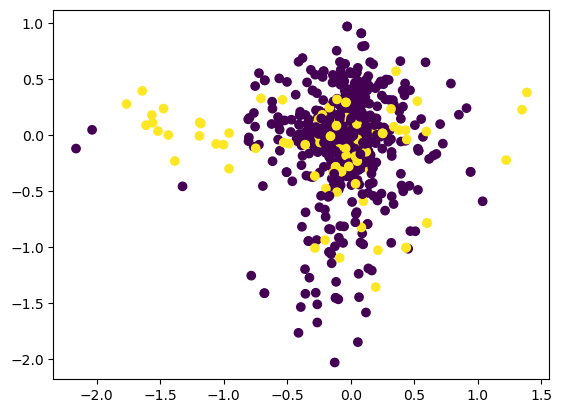

In [115]:
import matplotlib.pyplot as plt

plt.scatter(df_all["x_mean"], df_all["y_mean"], c=df_all["cluster"])
plt.show()

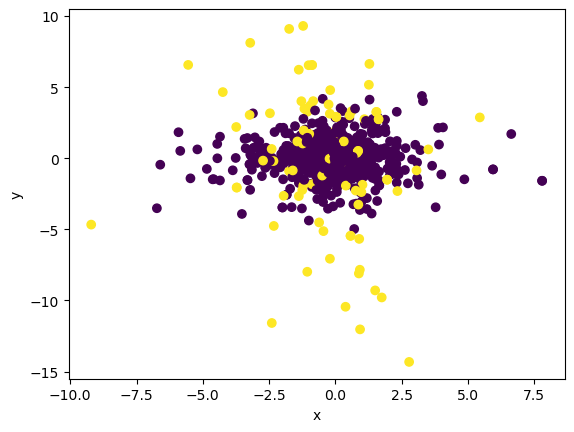

In [116]:
import matplotlib.pyplot as plt

plt.scatter(df_all["x"], df_all["y"], c=df_all["cluster"])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

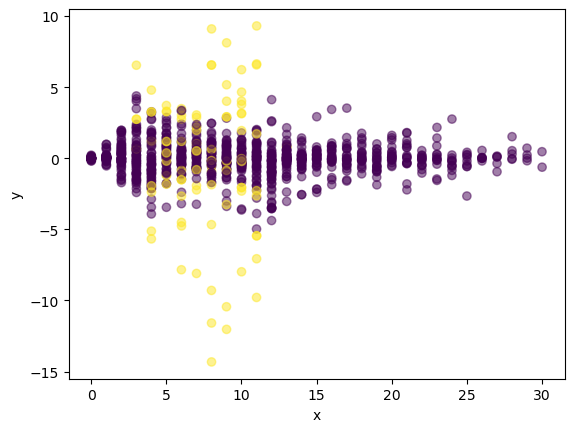

In [117]:
import matplotlib.pyplot as plt

plt.scatter(df_all["time"], df_all["y"], c=df_all["cluster"], alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [92]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
df_all["cluster"] = kmeans.fit_predict(x_scaled)
print(df_all.groupby("cluster")[feature].mean())

                x         y         z     x_std     y_std     z_std     x_rms  \
cluster                                                                         
0       -0.025173 -0.006657  0.152547  1.066820  0.861629  1.126338  1.084698   
1       -0.471401 -0.078208 -1.168735  1.597582  5.350706  5.858175  1.707769   

            y_rms     z_rms  
cluster                      
0        0.904228  1.154663  
1        5.335700  5.858390  


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


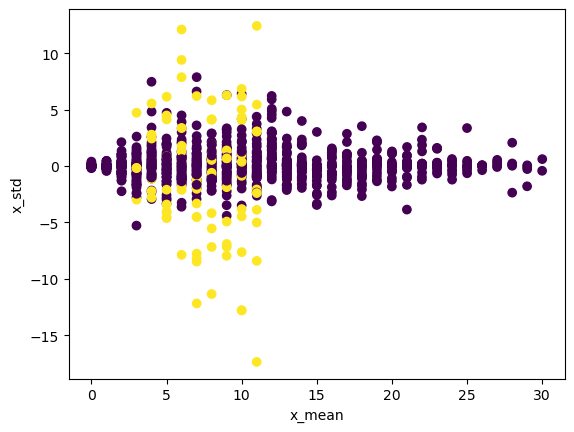

In [120]:
import matplotlib.pyplot as plt

plt.scatter(df_all["time"], df_all["z"], c=df_all["cluster"])
plt.xlabel("x_mean")
plt.ylabel("x_std")
plt.show()

In [80]:

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
df_all["cluster"] = dbscan.fit_predict(x_scaled)
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness,cluster
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400,-1
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212,-1
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190,-1
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434,-1


## opnieujwj

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


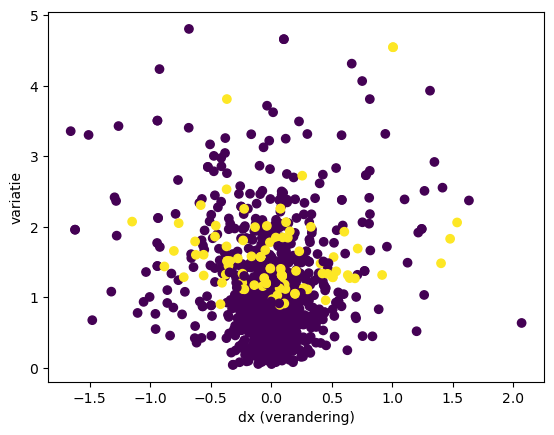

In [124]:
df_all["dx"] = df_all["x_mean"].diff()
features = [
    "dx",        # verschil = rem detectie
    "x_std",     # variatie
    "x_rms"
]
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df_all[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=0)
df_all["cluster"] = kmeans.fit_predict(x_scaled)
df_all.groupby("cluster")[["dx", "x_std"]].mean()

import matplotlib.pyplot as plt

plt.scatter(df_all["dx"], df_all["x_std"], c=df_all["cluster"])
plt.xlabel("dx (verandering)")
plt.ylabel("variatie")
plt.show()

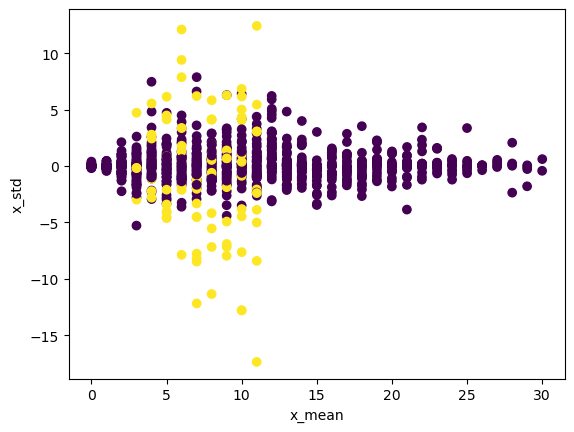

In [126]:
import matplotlib.pyplot as plt

plt.scatter(df_all["time"], df_all["z"], c=df_all["cluster"])
plt.xlabel("x_mean")
plt.ylabel("x_std")
plt.show()